# Unsupervised Structure Discovery (Density Clustering)

This notebook utilizes HDBSCAN to identify dense "clouds" of constructs.
We sweep hyperparameters (`cluster_selection_epsilon`, `min_cluster_size`) and optimize for F1-score on the calibration set (ground truth pairs).

In [1]:
import pandas as pd
import model_utils_clustering as model_utils
import model_utils_shared
import config
import warnings

# Silence warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Reproducibility
model_utils_shared.setup_reproducibility(config.SEED)

/home/rass/Desktop/SocialScience-ConceptIntegration/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


42

## 1. Load Data

In [2]:
pos_path = config.DATA_PATHS['pos_pairs']
neg_path = config.DATA_PATHS['neg_pairs']

df = model_utils_shared.load_and_prepare_data(pos_path, neg_path, config.SEED)
print(f"Total Rows: {len(df)}")

Loading datasets...
Positive samples: 3686
Negative samples (total): 2884741
Negative samples (sampled): 3686
Total Rows: 7372


## 2. Clustering Optimization Loop

Iterate through models and optimize HDBSCAN parameters.


 Processing: All-MPNet-Base-v2
Loading Model (all-mpnet-base-v2)...
Computed embeddings for 4277 unique terms.
Optimizing Clustering for All-MPNet-Base-v2...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using Original Embeddings (768 dims)...
768        | 2          | 2          | 0.5752     | 1.0000     | 0.4037     | 0.4037     | 1.0000
768        | 2          | 3          | 0.5139     | 0.9992     | 0.3459     | 0.3459     | 0.9997
768        | 2          | 4          | 0.3850     | 0.9989     | 0.2385     | 0.2385     | 0.9997
768        | 2          | 5          | 0.6087     | 0.5155     | 0.7431     | 0.7431     | 0.3017
768        | 2          | 6          | 0.5862     | 0.5141     | 0.6818     | 0.6818     | 0.3557
768        | 2          | 7          | 0.5946     | 0.5087     | 0.7154     | 0.7154     | 0.3090


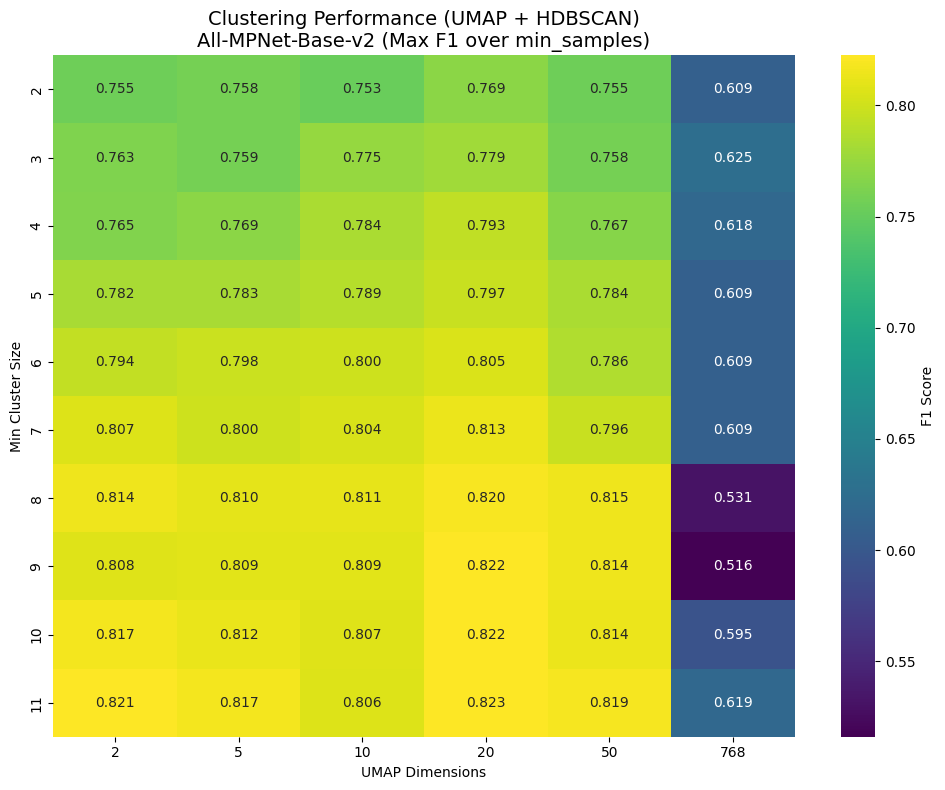


 Processing: MPNet-Personality
Loading Model (dwulff/mpnet-personality)...
Computed embeddings for 4277 unique terms.
Optimizing Clustering for MPNet-Personality...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using Original Embeddings (768 dims)...
768        | 2          | 2          | 0.5545     | 1.0000     | 0.3836     | 0.3836     | 1.0000
768        | 2          | 3          | 0.5077     | 1.0000     | 0.3402     | 0.3402     | 1.0000
768        | 2          | 4          | 0.4063     | 0.9989     | 0.2550     | 0.2550     | 0.9997
768        | 2          | 5          | 0.3347     | 0.9987     | 0.2010     | 0.2010     | 0.9997
768        | 2          | 6          | 0.2666     | 0.9982     | 0.1538     | 0.1538     | 0.9997
768        | 2          | 7          | 0.2001     | 0.9976     | 0.1112     | 0.1112     | 

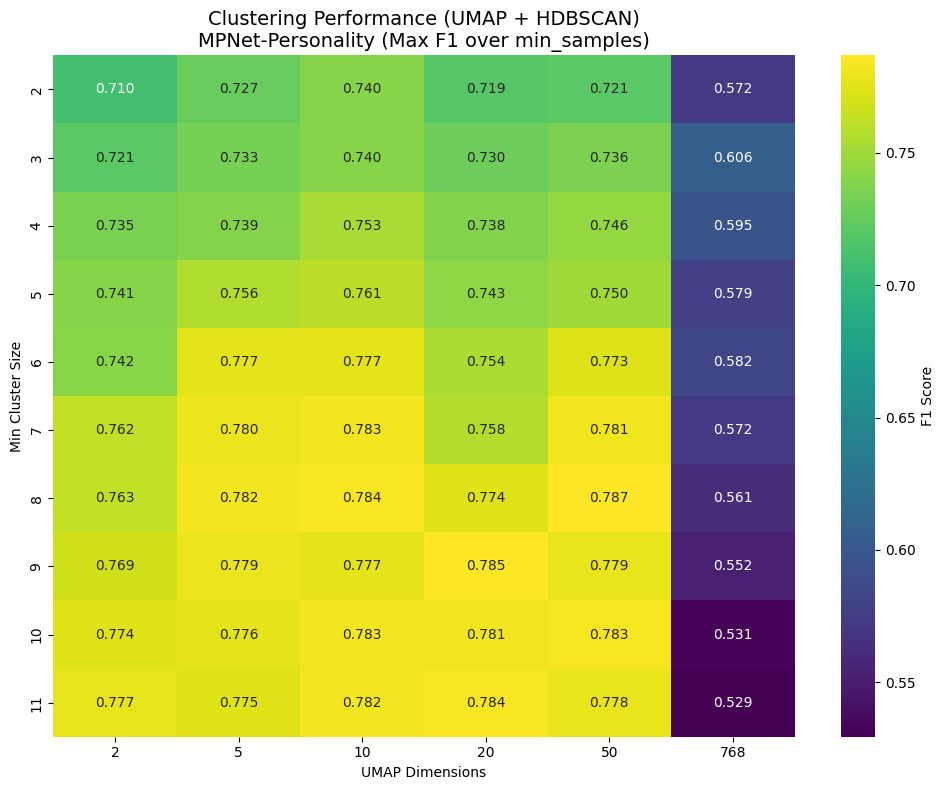


 Processing: SciBERT (SciVocab)
Loading Model (allenai/scibert_scivocab_uncased)...
Computed embeddings for 4277 unique terms.
Optimizing Clustering for SciBERT (SciVocab)...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using Original Embeddings (768 dims)...
768        | 2          | 2          | 0.3726     | 1.0000     | 0.2290     | 0.2290     | 1.0000
768        | 2          | 3          | 0.6625     | 0.5005     | 0.9797     | 0.9797     | 0.0222
768        | 2          | 4          | 0.6284     | 0.5058     | 0.8296     | 0.8296     | 0.1894
768        | 2          | 5          | 0.6055     | 0.5200     | 0.7246     | 0.7246     | 0.3310
768        | 2          | 6          | 0.6252     | 0.5049     | 0.8207     | 0.8207     | 0.1953
768        | 2          | 7          | 0.4653     | 0.5152     | 0.4243     | 0.4

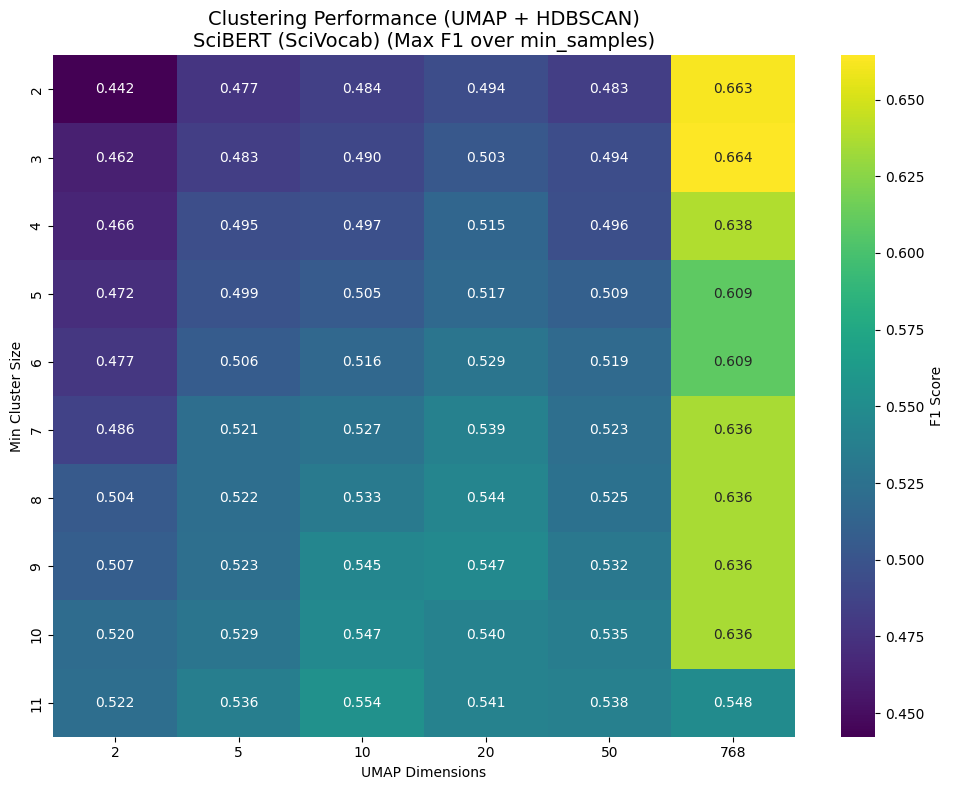


 Processing: BERT Base
Loading Model (bert-base-uncased)...
Computed embeddings for 4277 unique terms.
Optimizing Clustering for BERT Base...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using Original Embeddings (768 dims)...
768        | 2          | 2          | 0.3592     | 1.0000     | 0.2189     | 0.2189     | 1.0000
768        | 2          | 3          | 0.6401     | 0.4963     | 0.9012     | 0.9012     | 0.0855
768        | 2          | 4          | 0.6450     | 0.4947     | 0.9265     | 0.9265     | 0.0537
768        | 2          | 5          | 0.1365     | 0.9509     | 0.0735     | 0.0735     | 0.9962
768        | 2          | 6          | 0.4003     | 0.5103     | 0.3294     | 0.3294     | 0.6839
768        | 2          | 7          | 0.5500     | 0.4817     | 0.6411     | 0.6411     | 0.3101
768        | 2  

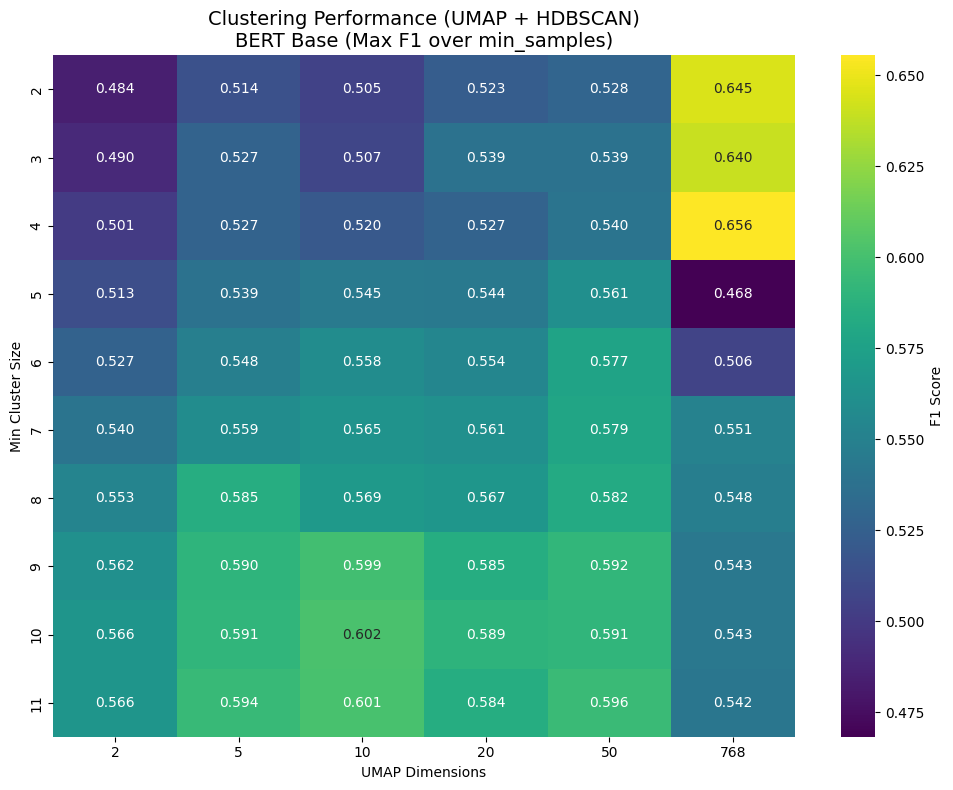

In [3]:
models_to_test = config.MODELS
all_clustering_results = []

for model_name, model_conf in models_to_test.items():
    display_name = model_conf['display_name']
    print(f"\n{'='*50}")
    print(f" Processing: {display_name}")
    print(f"{'='*50}")

    # 1. Load Model
    model = model_utils_shared.load_model(model_name, model_type=model_conf['type'])
    if model is None:
        continue

    # 2. Get Embeddings for unique terms
    unique_terms, embeddings = model_utils.get_unique_terms_embeddings(model, df)

    # 3. Sweep Hyperparameters (UMAP Components + Min Cluster Size)
    results, best_params = model_utils.run_clustering_optimization(
        model_name, 
        display_name, 
        unique_terms, 
        embeddings, 
        df, 
        config.CLUSTERING_PARAMS['min_cluster_sizes'],
        config.CLUSTERING_PARAMS['min_samples'],
        config.CLUSTERING_PARAMS['umap_n_components']
    )
    
    all_clustering_results.extend(results)

    # 4. Plot Heatmap
    results_df = pd.DataFrame(results)
    model_utils.plot_clustering_heatmap(results_df, display_name)

## 3. Summary of Best Clustering Configurations

In [ ]:
full_results_df = pd.DataFrame(all_clustering_results)

# Print Summary
model_utils.print_best_clustering_settings(full_results_df)

timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
full_results_df.to_csv(f'results/clustering_results_{timestamp}.csv', index=False)
print(f"\nFull clustering results saved to results/clustering_results_{timestamp}.csv")


 BEST CLUSTERING SETTINGS PER MODEL 

Model: All-MPNet-Base-v2
  Max F1: 0.7968
  Precision: 0.9939
  Recall: 0.6649
  Pos Acc: 0.6649
  Neg Acc: 0.9959
  UMAP Dims: 20
  Min Cluster Size: 5
  Clusters Found: 257
  Noise Points: 807

Model: MPNet-Personality
  Max F1: 0.7483
  Precision: 0.9950
  Recall: 0.5996
  Pos Acc: 0.5996
  Neg Acc: 0.9970
  UMAP Dims: 50
  Min Cluster Size: 5
  Clusters Found: 259
  Noise Points: 725

Model: SciBERT (SciVocab)
  Max F1: 0.5051
  Precision: 0.9759
  Recall: 0.3407
  Pos Acc: 0.3407
  Neg Acc: 0.9916
  UMAP Dims: 20
  Min Cluster Size: 5
  Clusters Found: 210
  Noise Points: 1026

Model: BERT Base
  Max F1: 0.5392
  Precision: 0.9913
  Recall: 0.3703
  Pos Acc: 0.3703
  Neg Acc: 0.9967
  UMAP Dims: 5
  Min Cluster Size: 5
  Clusters Found: 215
  Noise Points: 1321

Full clustering results saved to results/clustering_results_20260116_131627.csv
